# 

In [1]:
# import random
# random.seed(42)
# nodes = {
#     0: (0, 0), 1: (2, 5), 2: (8, 3), 3: (5, 9), 4: (1, 7),
#     5: (6, 4), 6: (9, 9), 7: (3, 1), 8: (7, 8), 9: (4, 4)
# }

# N = list(nodes.keys())
# Q = 7
# Depot = 0
# C = [i for i in nodes.keys() if i != Depot]
# K = range(3)
# q = {i: random.randint(1,5) for i in C}
# max(q)

In [2]:
import random
import pandas as pd
from random import randint
random.seed(1)
df = pd.read_excel("data/points.xlsx")
nodes = {int(row["node"]): (row["x"], row["y"]) for i, row in df.head(10).iterrows()}
N = list(nodes.keys())
Q = 15
Depot = 0
C = [i for i in nodes.keys() if i != Depot]
K = range(4)
q = {i: random.randint(1,4) for i in C if i != 7}
q[7] = 22


In [3]:
import math
distance = {}
for i in (N):
    for j in (N):
        if i == j:
            distance[i,j] = 0
        else:
            xi,yi = nodes[i]
            xj,yj = nodes[j]
            dx, dy = xi-xj , yi-yj
            distance[i,j] = math.hypot(dx,dy)

In [4]:
from ortools.sat.python import cp_model

In [5]:
model = cp_model.CpModel()

In [6]:
loadcar = {
    (i,k): model.NewIntVar(0, Q, f"load[{i},{k}]") 
    for i in C
    for k in K
}

y = {
    k: model.NewBoolVar(f"y[{k}]") 
    for k in K
}


z = {
    (i,k): model.NewBoolVar(f"z[{i},{k}]")
    for i in C
    for k in K
}

In [7]:
# for i in C:
#     for k in K:
#         model.Add(loadcar[i,k] > 0).OnlyEnforceIf(z[i,k])
#         model.Add(loadcar[i,k] == 0).OnlyEnforceIf(z[i,k].Not())
for i in C:
    for k in K:
        model.Add(loadcar[i,k] >= z[i,k])
        model.Add(loadcar[i,k] <= Q * z[i,k])
        

In [8]:
x = {}
for k in K:
    arcs = []
    for i in N:
        for j in N:
            if i!=j:
                x[i,j,k] = model.NewBoolVar(f"x[{i},{j},{k}]")
                arcs.append((i,j,x[i,j,k]))
            else:
                if i == j and i != Depot:
                    x[i,i,k] = z[i,k].Not()
                    arcs.append((i,i,x[i,i,k]))
                elif i == j and i == Depot:
                    x[Depot,Depot,k] = y[k].Not()
                    arcs.append((i,i,x[i,i,k]))
                
    model.AddCircuit(arcs)

In [9]:
for i in C: # demand sat
    model.Add(sum(loadcar[i,k] for k in K) == q[i])

In [10]:
for k in K: # vehicle capacity
    model.Add(sum(loadcar[i,k] for i in C) <= Q*y[k])
    

In [12]:
#symmetry break
for k in K[:-1]:
    model.Add(
        sum(loadcar[i,k] for i in C) >=
        sum(loadcar[i,k+1] for i in C)
    )
    
# for k in K[:-1]:
#     model.Add(y[k] >= y[k+1])

In [13]:
model.Minimize(sum(
    x[i,j,k]*distance[i,j]
              for i in N
              for j in N
              for k in K
            if i != j) + 1/100*y[k])

In [14]:
solver = cp_model.CpSolver()
status = solver.solve(model)
solver.WallTime()

1.9821524240000001

In [15]:
status

<CpSolverStatus.OPTIMAL: 4>

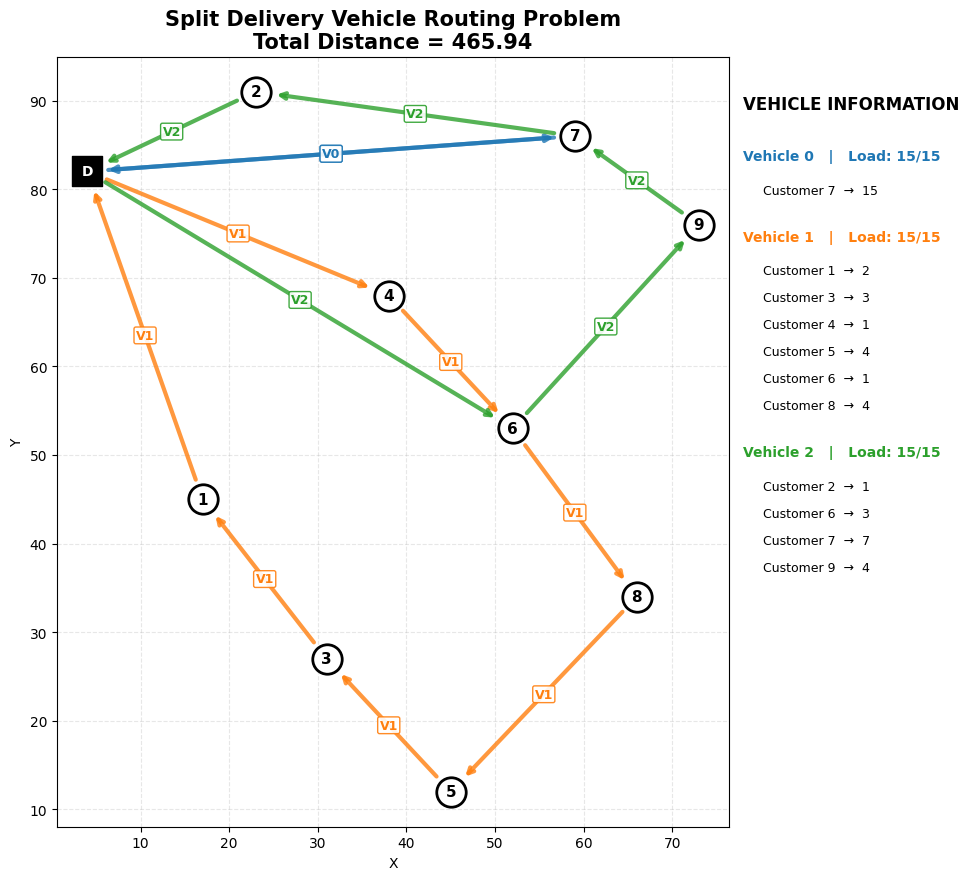

In [16]:
# Directly copy-pasted this part from AI
import matplotlib.pyplot as plt

coords = nodes
if status in (cp_model.OPTIMAL,cp_model.FEASIBLE):
    fig,ax=plt.subplots(figsize=(15,10)); colors=plt.cm.tab10.colors

    dx,dy=coords[Depot]
    ax.scatter(dx,dy,s=450,marker="s",color="black",zorder=10)
    ax.text(dx,dy,"D",color="white",ha="center",va="center",fontweight="bold",zorder=11)

    for i in C:
        xi,yi=coords[i]
        ax.scatter(xi,yi,s=450,facecolors="white",edgecolors="black",linewidth=2,zorder=10)
        ax.text(xi,yi,str(i),ha="center",va="center",fontsize=11,fontweight="bold",zorder=11)

    for k in K:
        if solver.Value(y[k])==0: continue
        color=colors[k%len(colors)]; route=[Depot]; current=Depot

        while True:
            next_node=next((j for j in N if j!=current and solver.Value(x[current,j,k])),None)
            if next_node is None: break
            route.append(next_node)
            if next_node==Depot: break
            current=next_node

        for a,b in zip(route[:-1],route[1:]):
            xa,ya=coords[a]; xb,yb=coords[b]
            ax.annotate("",xy=(xb,yb),xytext=(xa,ya),
                        arrowprops=dict(arrowstyle="->",color=color,linewidth=3,alpha=.8,shrinkA=15,shrinkB=15))
            ax.text((xa+xb)/2,(ya+yb)/2,f"V{k}",color=color,fontsize=9,fontweight="bold",
                    ha="center",va="center",bbox=dict(boxstyle="round,pad=.15",facecolor="white",edgecolor=color,alpha=.9))

    info_x,info_y=1.02,.95
    ax.text(info_x,info_y,"VEHICLE INFORMATION",transform=ax.transAxes,fontsize=12,fontweight="bold",va="top")
    y_pos=info_y-.07

    for k in K:
        if solver.Value(y[k])==0: continue
        color=colors[k%len(colors)]
        total_load=sum(solver.Value(loadcar[i,k]) for i in C)
        ax.text(info_x,y_pos,f"Vehicle {k}   |   Load: {total_load}/{Q}",
                transform=ax.transAxes,fontsize=10,fontweight="bold",color=color,va="top")
        y_pos-=.045

        for i in C:
            amount=solver.Value(loadcar[i,k])
            if amount>0:
                ax.text(info_x+.03,y_pos,f"Customer {i}  →  {amount}",
                        transform=ax.transAxes,fontsize=9,va="top")
                y_pos-=.035
        y_pos-=.025

    ax.set_title(f"Split Delivery Vehicle Routing Problem\nTotal Distance = {solver.ObjectiveValue():.2f}",
                 fontsize=15,fontweight="bold")
    ax.set_xlabel("X"); ax.set_ylabel("Y")
    ax.grid(True,linestyle="--",alpha=.3); ax.set_aspect("equal")
    plt.subplots_adjust(right=.72); plt.show()